# Assignment 6: Building Your First Neural Network

**Student Name:** [Madison zorman]

**Date:** [Date]

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.21.0


In [3]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv("train.csv")  # Replace with pd.read_csv()
test_df = pd.read_csv("test.csv")   # Replace with pd.read_csv()

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1).values
y_train = train_df['Activity'].values
X_test = test_df.drop('Activity', axis=1).values
y_test = test_df['Activity'].values

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [4]:
# TODO: Use StandardScaler to normalize features


# Fit on training data, transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data
X_test_scaled = scaler.transform(X_test)   # Replace with scaled test data

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [5]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')

baseline_model = keras.Sequential([
                     layers.Dense(64, activation='relu', input_shape=(562,)),
                     layers.Dense(6, activation='softmax')])

# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']
baseline_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

c:\Users\madfr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [6]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history =baseline_model.fit(X_train_scaled,y_train, epochs=20,validation_split=0.2)  # Replace with model.fit() result

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)  # Replace with model.evaluate()

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8939 - loss: 0.2934 - val_accuracy: 0.9252 - val_loss: 0.2066
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9704 - loss: 0.0907 - val_accuracy: 0.9273 - val_loss: 0.1933
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9803 - loss: 0.0626 - val_accuracy: 0.9320 - val_loss: 0.1928
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9828 - loss: 0.0498 - val_accuracy: 0.9320 - val_loss: 0.2048
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9867 - loss: 0.0403 - val_accuracy: 0.9286 - val_loss: 0.2163
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9327 - val_loss: 0.2247
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9898 - loss: 0.0304 - val_accuracy: 0.9354 - val_loss: 0.2339
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [7]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile with same settings as baseline
medium_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)  # Replace with model.fit() result

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test_scaled, y_test, verbose=0)  # Replace with model.evaluate()

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8959 - loss: 0.2639 - val_accuracy: 0.9341 - val_loss: 0.1526
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9725 - loss: 0.0777 - val_accuracy: 0.9354 - val_loss: 0.1702
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9793 - loss: 0.0617 - val_accuracy: 0.9375 - val_loss: 0.1768
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9808 - loss: 0.0499 - val_accuracy: 0.9368 - val_loss: 0.1776
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9874 - loss: 0.0333 - val_accuracy: 0.9375 - val_loss: 0.1966
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9908 - loss: 0.0277 - val_accuracy: 0.9409 - val_loss: 0.2113
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9918 - loss: 0.0226 - val_accuracy: 0.9409 - val_loss: 0.2140
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accur

### Deep Network (3 Layers)

In [8]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile with same settings
deep_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2 )  # Replace with model.fit() result

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test_scaled, y_test, verbose=0)  # Replace with model.evaluate()

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8706 - loss: 0.3248 - val_accuracy: 0.9184 - val_loss: 0.1730
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9685 - loss: 0.0857 - val_accuracy: 0.9341 - val_loss: 0.1609
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9784 - loss: 0.0608 - val_accuracy: 0.9402 - val_loss: 0.1545
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.0567 - val_accuracy: 0.9361 - val_loss: 0.1686
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9855 - loss: 0.0361 - val_accuracy: 0.9327 - val_loss: 0.1946
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0269 - val_accuracy: 0.9436 - val_loss: 0.1872
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9905 - loss: 0.0250 - val_accuracy: 0.9375 - val_loss: 0.1961
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accurac

### Compare Depth Experiments

In [9]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.918222
    2 Layers (128, 64)       0.922973
3 Layers (128, 64, 32)       0.921955


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

At first, with the addition of the second layer, the accuracy had been improved, but once the third layer was added, the accuracy of the model started to decrease. This could be due to overfitting.

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [10]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(562,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
narrow_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(X_train_scaled, y_train, epochs=20,batch_size=32, validation_split=0.2)  # Replace with model.fit() result

# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(X_test_scaled, y_test)  # Replace with model.evaluate()

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20


c:\Users\madfr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8609 - loss: 0.3873 - val_accuracy: 0.9429 - val_loss: 0.1460
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9660 - loss: 0.1019 - val_accuracy: 0.9375 - val_loss: 0.1381
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9777 - loss: 0.0666 - val_accuracy: 0.9436 - val_loss: 0.1321
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0528 - val_accuracy: 0.9415 - val_loss: 0.1410
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9859 - loss: 0.0421 - val_accuracy: 0.9436 - val_loss: 0.1568
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9872 - loss: 0.0372 - val_accuracy: 0.9402 - val_loss: 0.1746
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0322 - val_accuracy: 0.9381 - val_loss: 0.1949
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9896 - loss: 0.0303 - val_accuracy: 0.9375 - val_

### Medium Width Network (2 Layers, 64 Nodes Each)

In [11]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(562,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
medium_width_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)  # Replace with model.fit() result

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(X_test_scaled, y_test)  # Replace with model.evaluate()

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8733 - loss: 0.3262 - val_accuracy: 0.9184 - val_loss: 0.2053
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.0915 - val_accuracy: 0.9211 - val_loss: 0.2093
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9799 - loss: 0.0592 - val_accuracy: 0.9320 - val_loss: 0.1987
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9820 - loss: 0.0458 - val_accuracy: 0.9313 - val_loss: 0.2105
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9866 - loss: 0.0374 - val_accuracy: 0.9313 - val_loss: 0.2298
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9896 - loss: 0.0323 - val_accuracy: 0.9327 - val_loss: 0.2465
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9913 - loss: 0.0275 - val_accuracy: 0.9327 - val_loss: 0.2689
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

### Wide Network (2 Layers, 128 Nodes Each)

In [12]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
wide_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)  # Replace with model.fit() result

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test_scaled, y_test)  # Replace with model.evaluate()

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8988 - loss: 0.2636 - val_accuracy: 0.9273 - val_loss: 0.1569
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9685 - loss: 0.0844 - val_accuracy: 0.9381 - val_loss: 0.1440
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0566 - val_accuracy: 0.9388 - val_loss: 0.1583
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0500 - val_accuracy: 0.9354 - val_loss: 0.1667
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9794 - loss: 0.0571 - val_accuracy: 0.9402 - val_loss: 0.1817
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9876 - loss: 0.0337 - val_accuracy: 0.9395 - val_loss: 0.2076
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9927 - loss: 0.0232 - val_accuracy: 0.9415 - val_loss: 0.2339
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

### Compare Width Experiments

In [13]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.917204
 2 Layers (64 each)       0.926705
2 Layers (128 each)       0.942993


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

When the model was run with 64 nodes, the accuracy had decreased from when it was run with 32. Then the accuracy had increased when run with 128 nodes.

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [14]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(562,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# TODO: Compile the model
best_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split=0.2)  # Replace with model.fit() result

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test_scaled, y_test)  # Replace with model.evaluate()

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [Describe your architecture here]")
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

Training best model for 30 epochs...
Epoch 1/30


c:\Users\madfr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8987 - loss: 0.2644 - val_accuracy: 0.9279 - val_loss: 0.1715
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9687 - loss: 0.0834 - val_accuracy: 0.9443 - val_loss: 0.1425
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9752 - loss: 0.0664 - val_accuracy: 0.9368 - val_loss: 0.1615
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9842 - loss: 0.0435 - val_accuracy: 0.9422 - val_loss: 0.1591
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9878 - loss: 0.0328 - val_accuracy: 0.9375 - val_loss: 0.1696
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9881 - loss: 0.0335 - val_accuracy: 0.9381 - val_loss: 0.2048
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0228 - val_accuracy: 0.9395 - val_loss: 0.1974
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9940 - loss: 0.0176 - val_accuracy: 0.9443 - val_

### Visualize Training Progress - Accuracy

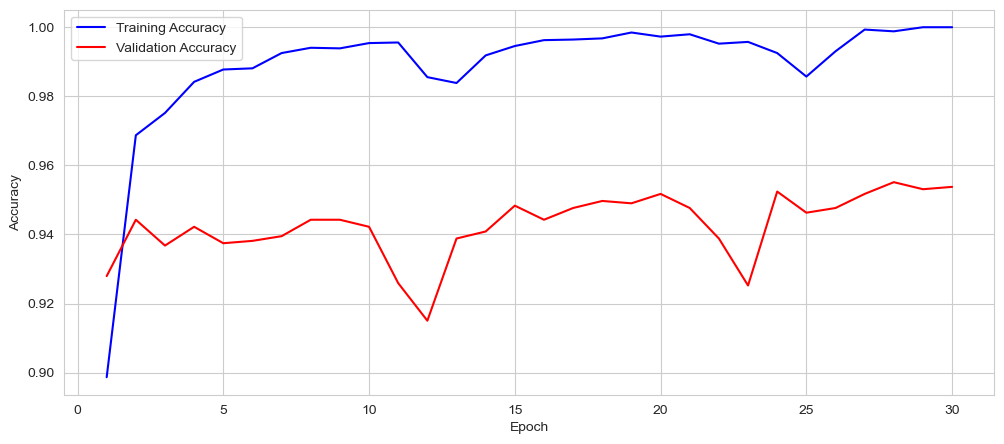

In [15]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']
train_accuracy = best_history.history['accuracy']
val_accuracy = best_history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

if best_history is not None:
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r-',label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

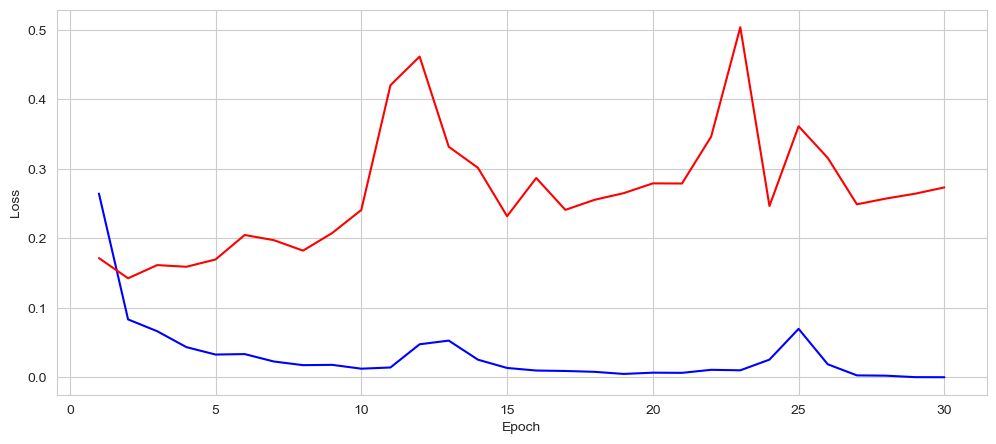

In [16]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']

train_loss = best_history.history['loss']
val_loss = best_history.history['val_loss']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.plot(epochs, train_loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss,'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
   
    
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [20]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.863590    # Replace with your Unit 7 test accuracy
unit7_pca_rf_time =2.266002 # Replace with your Unit 7 training time (if you have it)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (2 layers, 128 nodes each)',  # Replace with your architecture description
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '2 hidden layers',
        '30 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                             Model   Features/Layers  Test Accuracy Training Time
   Baseline NN (1 layer, 64 nodes)    1 hidden layer       0.918222        12.70s
Best NN (2 layers, 128 nodes each)   2 hidden layers       0.927044        23.46s
       Unit 7: PCA + Random Forest 30 PCA components       0.863590         2.27s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

Compared to PCA+random forest, the tests run by the neural network were much more accurate. The downside to this increased accuracy is the longer training time. The neural network took 10 times longer to train, but with that extra time, it gained an additional 0.063 in accuracy.

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

Neural networks should be used when interpretability isn't necessary for large, complex, and unstructured data sets. They are also better suited for data made up of images, sensor data, and text data. A situation where neural networks would be best suited is when x-rays and other types of medical imaging need to be analyzed to search for commonalities that will assist with diagnosing diseases.

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.